In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
#mpl.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
sns.set_style("white")
sns.set_style("ticks") 

from moviepy.editor import VideoClip
from moviepy.video.io.bindings import mplfig_to_npimage

from scipy.stats import ttest_ind

C:\Users\egc34\AppData\Local\Continuum\anaconda3\lib\site-packages\statsmodels\tools\_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [2]:
adapt='Slow_Down'

In [3]:
"""
Load data in as dictionary where keys are frame number (t1,t2,etc.) and key into numpy array with the following columns:
1) Pixel index
2) Normalized (?)
3) X
4) Y
5) X_um
6) Y_um
7) RFP
8) GCaMP
9) RFP-GCaMP_Ratio
10) GCaMP_adj_x
11) GCaMP_adj_y
The remaining columns all have the same value for each row (pixel)
12) Soma_RFP_X position
13) Soma_RFP_Y position
14) Soma_RFP_Mean_Value
15) Soma_GCaMP_X position
16) Soma_GCaMP_Y position
17) Soma_GCaMP_Mean_Value
"""
import glob
numFrames = len(glob.glob("input/CSVs_Multi/*.csv"))
print(numFrames)
data = {}
lacking_data = []
for i in range(numFrames):
    name = "input/CSVs_Multi/GCY8Mix_8.2_Tc25_17to24_1__2_MMStack_t"+str(i+1)+".csv"
    temp = np.loadtxt(name, delimiter=',', skiprows=1)
    #print np.shape(temp)
    if len(np.shape(temp)) < 2:
        #print (i+1),"This frame is lacking data"
        lacking_data.append(i+1)
        continue
    else:
        data[str(i+1)] = temp
        
print(lacking_data)

meta_dict = {}
with open("input/CSVs_Multi/GCY8Mix_8.2_Tc25_17to24_1__2_MMStack_Pos0_metadata.txt", "r") as metadata:
    for line in metadata:
        pieces = line.split(":")
        if len(pieces) < 2:
            continue
        else:
            if "FrameKey" in pieces[0]:
                key = str(int(pieces[0].split("-")[1])+1)
                meta_dict[key] = {}
            else:
                if eval(pieces[0].strip()) == "MeasuredStageX":
                    meta_dict[key]["StageX"] = float(pieces[1].strip().strip(','))
                elif eval(pieces[0].strip()) == "MeasuredStageY":
                    meta_dict[key]["StageY"] = float(pieces[1].strip().strip(','))
                elif eval(pieces[0].strip()) == "ElapsedTime-ms":
                    meta_dict[key]["ElapsedTime"] = float(pieces[1].strip().strip(','))

4995
[24, 25, 26, 27, 88, 89, 90, 197, 198, 390, 467, 468, 469, 470, 472, 474, 475, 603, 604, 606, 737, 738, 739, 740, 741, 742, 743, 744, 745, 746, 747, 748, 749, 750, 1060, 1219, 1221, 1276, 1302, 1303, 1304, 1475, 1730, 1951, 2153, 2854, 2855, 2856, 2860, 2861, 2862, 3031, 3032, 3033, 3034, 3685, 4046, 4126, 4157, 4158, 4162, 4165, 4194, 4195, 4196, 4389, 4391, 4394, 4395, 4519, 4520, 4988]


In [4]:
xFOV = []
yFOV = []
frame_list4 = []
for frame in data.keys():
    xFOV.append(meta_dict[frame]["StageX"])
    yFOV.append(meta_dict[frame]["StageY"])
    frame_list4.append(int(frame))
frame_list_sorted4, xFOV_sorted = (list(t) for t in zip(*sorted(zip(frame_list4, xFOV))))
frame_list_sorted4, yFOV_sorted = (list(t) for t in zip(*sorted(zip(frame_list4, yFOV))))

In [5]:
print(len(xFOV))

4923


In [6]:
NeuronXPos = []
NeuronYPos = []
frame_list5 = []
for frame in data.keys():
    NeuronXPos.append(np.nanmean(data[frame][:,11])*1.26)
    NeuronYPos.append(np.nanmean(data[frame][:,12])*1.26)
    frame_list5.append(int(frame))
frame_list_sorted5, NeuronXPos_sorted = (list(t) for t in zip(*sorted(zip(frame_list5, NeuronXPos))))
frame_list_sorted6, NeuronYPos_sorted = (list(t) for t in zip(*sorted(zip(frame_list5, NeuronYPos))))

#print frame_list_sorted5

In [7]:
xVal = []
deltaX = []
X0 = 15544.999 #this is position at right courner of stage where temp is Xc
for i in range(len(NeuronXPos_sorted)):
    neuron_pos = NeuronXPos_sorted[i]+xFOV_sorted[i]
    xVal.append(neuron_pos)
    deltaX.append(neuron_pos - X0)

In [8]:
Gradient=1.0
Origin=17

In [9]:
steepness=((Gradient)*10**-4) #converting gradient steepnes to celcius/um
deltaT=[]
TxTip = []
for i in range(len(deltaX)):
    temp_change = deltaX[i]*steepness
    deltaT.append(temp_change)
    TxTip.append(temp_change+Origin)
    
#print TxTip

<Figure size 432x288 with 0 Axes>

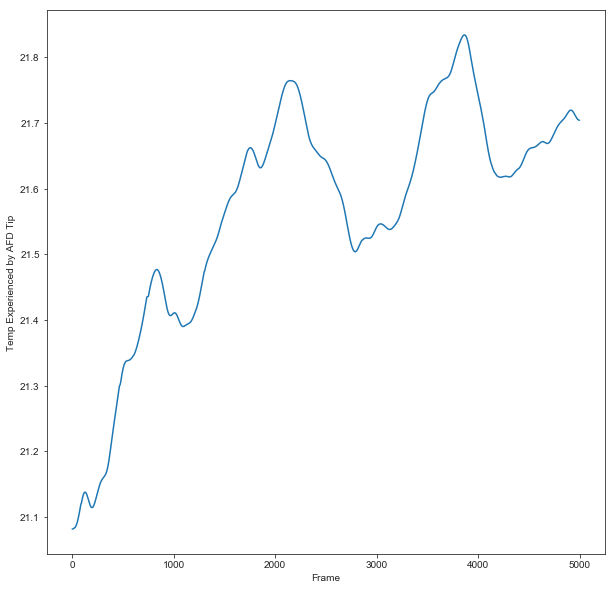

In [10]:
smoothed_TxTip = gaussian_filter1d(TxTip, sigma=30)
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(frame_list_sorted5,smoothed_TxTip)
plt.xlabel('Frame')
plt.ylabel('Temp Experienced by AFD Tip')
plt.show()

In [11]:
yVal = []
for i in range(len(NeuronYPos_sorted)):
    neuron_pos = (NeuronYPos_sorted[i]+yFOV_sorted[i])*(-1)
    yVal.append(neuron_pos)

In [12]:
Time = []
frame_list8 = []
for frame in meta_dict.keys():
    if int(frame) in lacking_data:
        continue
    else:
        Time.append(float(meta_dict[frame]["ElapsedTime"])/1000)
        frame_list8.append(int(frame))
frame_list_sorted8, Time_sorted = (list(t) for t in zip(*sorted(zip(frame_list8, Time))))

if frame_list_sorted8 == frame_list_sorted6:
    print('yay')
else:
    print(len(frame_list_sorted6), len(frame_list_sorted8))
    
diffT = [0] + list(np.diff(Time_sorted))
print(diffT)
#print list(np.diff(Time_sorted))

yay
[0, 0.1449999999999999, 0.006000000000000005, 0.0050000000000000044, 0.01100000000000001, 0.0050000000000000044, 0.006000000000000005, 0.0050000000000000044, 0.026000000000000023, 0.04300000000000004, 0.02499999999999991, 0.02400000000000002, 0.04300000000000004, 0.02400000000000002, 0.040999999999999925, 0.6819999999999999, 0.006000000000000005, 0.0050000000000001155, 0.026000000000000023, 0.026000000000000023, 0.04299999999999993, 0.026999999999999913, 0.04500000000000015, 0.1519999999999999, 0.025000000000000133, 0.04400000000000004, 0.7189999999999999, 0.008000000000000007, 0.007000000000000117, 0.02400000000000002, 0.040999999999999925, 0.02400000000000002, 0.040999999999999925, 0.02499999999999991, 0.04400000000000004, 0.02499999999999991, 0.04400000000000004, 0.028999999999999915, 0.026000000000000245, 0.02499999999999991, 0.04499999999999993, 0.698, 0.006000000000000227, 0.005999999999999783, 0.02400000000000002, 0.02499999999999991, 0.04400000000000004, 0.04400000000000048

In [13]:
print(len(Time))

4923


<Figure size 432x288 with 0 Axes>

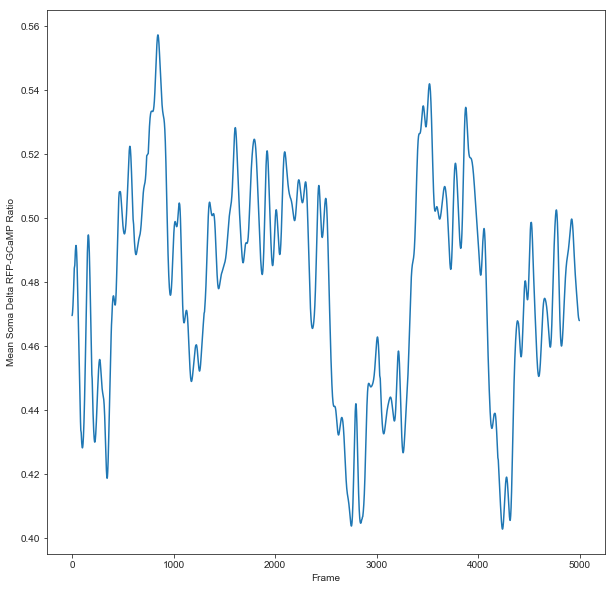

In [14]:
Soma_RFP_mean = []
Soma_GCaMP_mean = []
SomaRatio = []
frame_list7 = []
for frame in data.keys():
    temp_RFP = np.nanmean(list(data[frame][:,13].astype(float)))
    temp_GCaMP = np.nanmean(list(data[frame][:,16].astype(float)))
    Soma_RFP_mean.append(temp_RFP)
    Soma_GCaMP_mean.append(temp_GCaMP)
    SomaRatio.append(temp_GCaMP/temp_RFP)
    frame_list7.append(int(frame))
    
frame_list_sorted7, Soma_RFP_mean_sorted, Soma_GCaMP_mean_sorted, Soma_Ratio_sorted = (list(t) for t in zip(*sorted(zip(frame_list7,\
                                                            Soma_RFP_mean, Soma_GCaMP_mean, SomaRatio))))


#where_out = eng.isoutlier(matlab.single(Soma_Ratio_sorted), 'mean')
#Soma_Ratio_sorted_outlierTrim = np.where(where_out, np.nan, Soma_Ratio_sorted)[0].tolist()
Soma_Ratio_smoothed = gaussian_filter1d(Soma_Ratio_sorted, sigma=17)

plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(frame_list_sorted7,Soma_Ratio_smoothed)
plt.xlabel('Frame')
plt.ylabel('Mean Soma Delta RFP-GCaMP Ratio')
plt.show()

<Figure size 432x288 with 0 Axes>

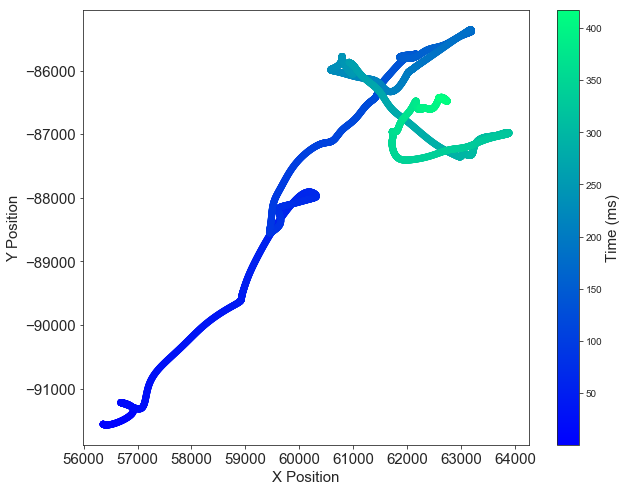

In [15]:
xVals_smoothed = gaussian_filter1d(xVal, sigma=30)
yVals_smoothed = gaussian_filter1d(yVal, sigma=30)

plt.clf()
plt.figure(figsize=(10,8))#,dpi=300)#plt.ylim(0,1)
plt.scatter(xVals_smoothed, yVals_smoothed, c=Time_sorted, cmap='winter')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)
plt.xlabel('X Position', fontsize=15)
plt.ylabel('Y Position', fontsize=15)
cb = plt.colorbar()
cb.set_label('Time (ms)', fontsize=15)
plt.show()

<Figure size 432x288 with 0 Axes>

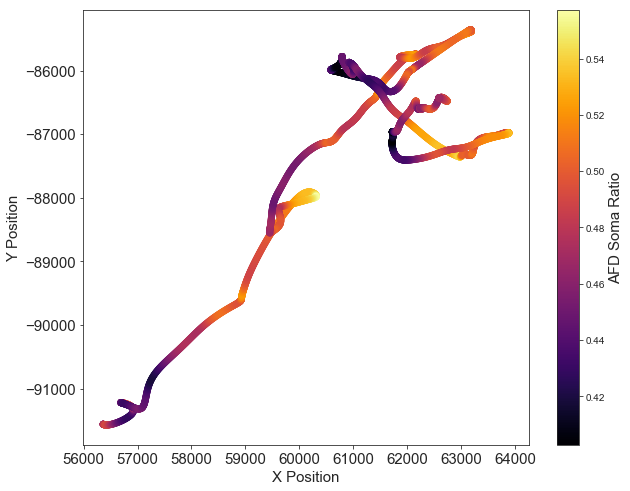

In [16]:
plt.clf()
plt.figure(figsize=(10,8))#,dpi=300)#plt.ylim(0,1)
plt.scatter(xVals_smoothed, yVals_smoothed, c=Soma_Ratio_smoothed, cmap='inferno', vmin=min(Soma_Ratio_smoothed), vmax=max(Soma_Ratio_smoothed))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)
plt.xlabel('X Position', fontsize=15)
plt.ylabel('Y Position', fontsize=15)
cb = plt.colorbar()
cb.set_label('AFD Soma Ratio', fontsize=15)
plt.show()

In [17]:
numFrames = len(glob.glob("input/CSVs_Multi/*.csv"))
#print numFrames
data = {}
lacking_data = []
for i in range(numFrames):
    name = "input_1_3/CSVs_Multi/GCY8Mix_8.2_Tc25_17to24_1__3_MMStack_t"+str(i+1)+".csv"
    temp = np.loadtxt(name, delimiter=',', skiprows=1)
    #print np.shape(temp)
    if len(np.shape(temp)) < 2:
        #print (i+1),"This frame is lacking data"
        lacking_data.append(i+1)
        continue
    else:
        data[str(i+1)] = temp
        
print(lacking_data)

meta_dict = {}
with open("input_1_3/CSVs_Multi/GCY8Mix_8.2_Tc25_17to24_1__3_MMStack_Pos0_metadata.txt", "r") as metadata:
    for line in metadata:
        pieces = line.split(":")
        if len(pieces) < 2:
            continue
        else:
            if "FrameKey" in pieces[0]:
                key = str(int(pieces[0].split("-")[1])+1)
                meta_dict[key] = {}
            else:
                if eval(pieces[0].strip()) == "MeasuredStageX":
                    meta_dict[key]["StageX"] = float(pieces[1].strip().strip(','))
                elif eval(pieces[0].strip()) == "MeasuredStageY":
                    meta_dict[key]["StageY"] = float(pieces[1].strip().strip(','))
                elif eval(pieces[0].strip()) == "ElapsedTime-ms":
                    meta_dict[key]["ElapsedTime"] = float(pieces[1].strip().strip(','))

[499, 500, 503, 506, 787, 809, 810, 866, 868, 3308, 3491, 3494, 3495, 4367, 4368]


In [18]:
prev_frame = max(frame_list_sorted8)
for frame in data.keys():
    xFOV.append(meta_dict[frame]["StageX"])
    yFOV.append(meta_dict[frame]["StageY"])
    frame_list4.append(int(frame)+prev_frame)
frame_list_sorted4, xFOV_sorted = (list(t) for t in zip(*sorted(zip(frame_list4, xFOV))))
frame_list_sorted4, yFOV_sorted = (list(t) for t in zip(*sorted(zip(frame_list4, yFOV))))

In [19]:
print(len(xFOV))

9903


In [20]:
for frame in data.keys():
    NeuronXPos.append(np.nanmean(data[frame][:,11])*1.26)
    NeuronYPos.append(np.nanmean(data[frame][:,12])*1.26)
    frame_list5.append(int(frame)+prev_frame)
frame_list_sorted5, NeuronXPos_sorted = (list(t) for t in zip(*sorted(zip(frame_list5, NeuronXPos))))
frame_list_sorted6, NeuronYPos_sorted = (list(t) for t in zip(*sorted(zip(frame_list5, NeuronYPos))))

#print frame_list_sorted5

In [21]:
xVal = []
deltaX = []
X0 = 15544.999 #this is position at right courner of stage where temp is Xc
for i in range(len(NeuronXPos_sorted)):
    neuron_pos = NeuronXPos_sorted[i]+xFOV_sorted[i]
    xVal.append(neuron_pos)
    deltaX.append(neuron_pos - X0)

In [22]:
Gradient=1.0
Origin=17

In [23]:
steepness=((Gradient)*10**-4) #converting gradient steepnes to celcius/um
deltaT=[]
TxTip = []
for i in range(len(deltaX)):
    temp_change = deltaX[i]*steepness
    deltaT.append(temp_change)
    TxTip.append(temp_change+Origin)
    
#print TxTip

<Figure size 432x288 with 0 Axes>

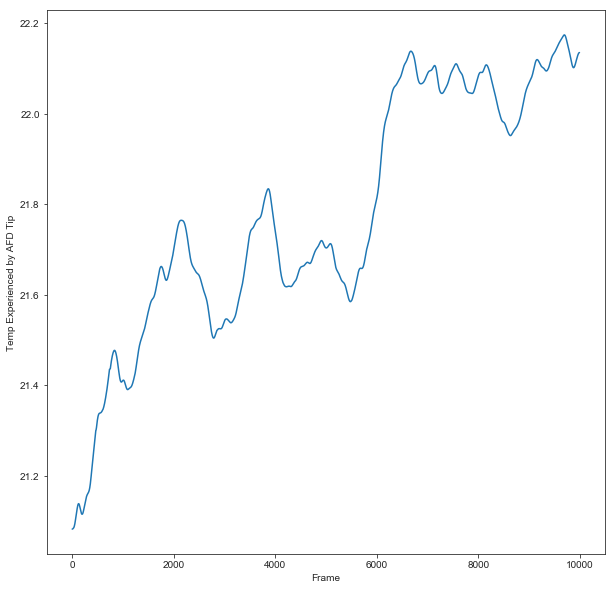

In [24]:
smoothed_TxTip = gaussian_filter1d(TxTip, sigma=30)
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(frame_list_sorted5,smoothed_TxTip)
plt.xlabel('Frame')
plt.ylabel('Temp Experienced by AFD Tip')
plt.show()

In [25]:
yVal = []
for i in range(len(NeuronYPos_sorted)):
    neuron_pos = (NeuronYPos_sorted[i]+yFOV_sorted[i])*(-1)
    yVal.append(neuron_pos)

In [26]:
start_time = float(max(Time))
print(start_time)
for frame in data.keys():
    Time.append((float(meta_dict[frame]["ElapsedTime"])/1000)+start_time)
    frame_list8.append(int(frame)+prev_frame)
frame_list_sorted8, Time_sorted = (list(t) for t in zip(*sorted(zip(frame_list8, Time))))

if frame_list_sorted8 == frame_list_sorted6:
    print('yay')
else:
    print(len(frame_list_sorted6), len(frame_list_sorted8))
    
diffT = [0] + list(np.diff(Time_sorted))
#print(diffT)
#print list(np.diff(Time_sorted))

417.282
yay


In [27]:
print(len(Time))
print(Time)

9903
[0.545, 0.69, 0.696, 0.701, 0.712, 0.717, 0.723, 0.728, 0.754, 0.797, 0.822, 0.846, 0.889, 0.913, 0.954, 1.636, 1.642, 1.647, 1.673, 1.699, 1.742, 1.769, 1.814, 1.966, 1.991, 2.035, 2.754, 2.762, 2.769, 2.793, 2.834, 2.858, 2.899, 2.924, 2.968, 2.993, 3.037, 3.066, 3.092, 3.117, 3.162, 3.86, 3.866, 3.872, 3.896, 3.921, 3.965, 4.009, 4.036, 4.061, 4.103, 4.13, 4.157, 4.2, 4.224, 4.265, 5.149, 5.16, 5.17, 5.178, 5.184, 5.191, 5.198, 5.205, 5.211, 5.217, 5.24, 5.286, 5.316, 5.344, 5.371, 6.141, 6.147, 6.155, 6.162, 6.185, 6.21, 6.254, 6.28, 6.305, 6.347, 6.373, 6.4, 7.255, 7.263, 7.273, 7.298, 7.322, 7.366, 7.39, 7.433, 7.46, 7.487, 7.53, 7.556, 7.582, 7.626, 7.652, 8.411, 8.419, 8.426, 8.433, 8.456, 8.479, 8.504, 8.579, 8.584, 8.607, 8.648, 8.674, 8.698, 8.742, 8.767, 9.418, 9.428, 9.436, 9.463, 9.489, 9.534, 9.563, 9.587, 9.631, 9.657, 9.681, 9.722, 9.747, 9.789, 9.814, 10.558, 10.567, 10.574, 10.58, 10.586, 10.629, 10.656, 10.701, 10.727, 10.754, 10.799, 10.826, 10.851, 10.894, 10

In [28]:
## 1/29 Trying different up and down kinestics ###

#dif_T = 0.1
#starting with tau = 45 seconds, time between temp aquisitions is 1/10 of second

theta_smooth = np.array(smoothed_TxTip-0.01)
for i in range(1,len(smoothed_TxTip)):
    if smoothed_TxTip[i] > theta_smooth[i-1]:
        #tau = 45
        tau = 840
    elif smoothed_TxTip[i] <= theta_smooth[i-1]:
        if adapt == 'Fast_Down':
            tau = 45
        elif adapt == 'Slow_Down':
            tau = 840
    theta_smooth[i] = theta_smooth[i-1] + ((smoothed_TxTip[i]-theta_smooth[i-1])/tau)*diffT[i]

<Figure size 432x288 with 0 Axes>

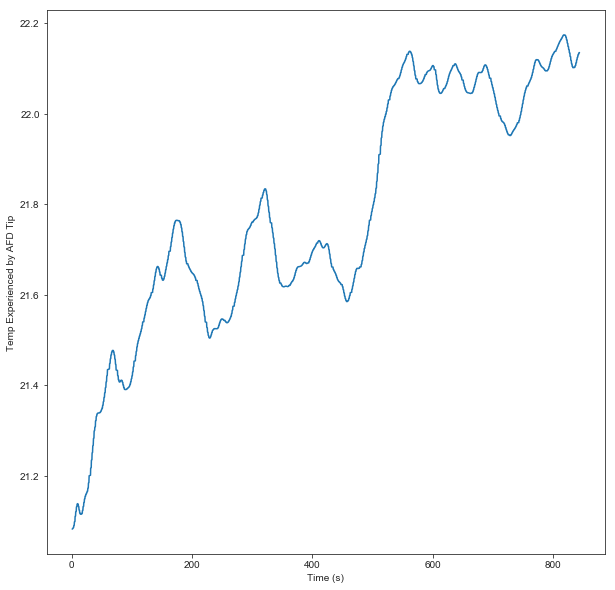

In [29]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(Time_sorted,smoothed_TxTip)
#plt.plot(Time_sorted,theta_smooth)
plt.xlabel('Time (s)')
plt.ylabel('Temp Experienced by AFD Tip')
plt.show()

<Figure size 432x288 with 0 Axes>

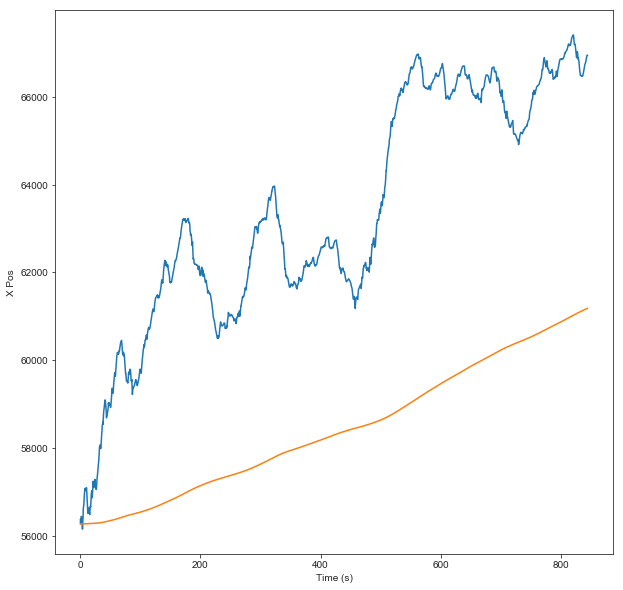

In [30]:
Theta_XPos = []
for i in range(len(theta_smooth)):
    Theta_XPos.append(((theta_smooth[i]-Origin)/steepness)+X0)
    
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(Time_sorted,xVal)
plt.plot(Time_sorted,Theta_XPos)
plt.xlabel('Time (s)')
plt.ylabel('X Pos')
plt.show()

<Figure size 432x288 with 0 Axes>

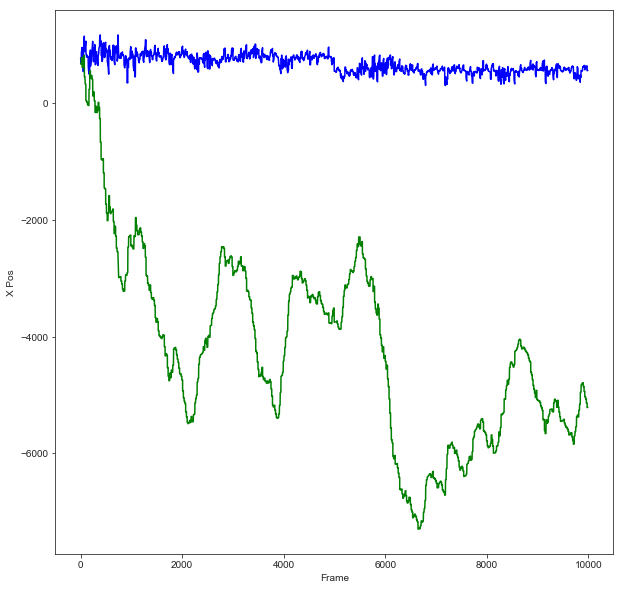

In [31]:
Theta_XinFOV = []
for i in range(len(Theta_XPos)):
    Theta_XinFOV.append(Theta_XPos[i]-xFOV_sorted[i])
    
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(frame_list_sorted8,NeuronXPos_sorted, 'b')
plt.plot(frame_list_sorted8,Theta_XinFOV, 'g')
plt.xlabel('Frame')
plt.ylabel('X Pos')
plt.show()

Theta_XinPixels = []
for i in range(len(Theta_XinFOV)):
    Theta_XinPixels.append(float(Theta_XinFOV[i])/1.26)

<Figure size 432x288 with 0 Axes>

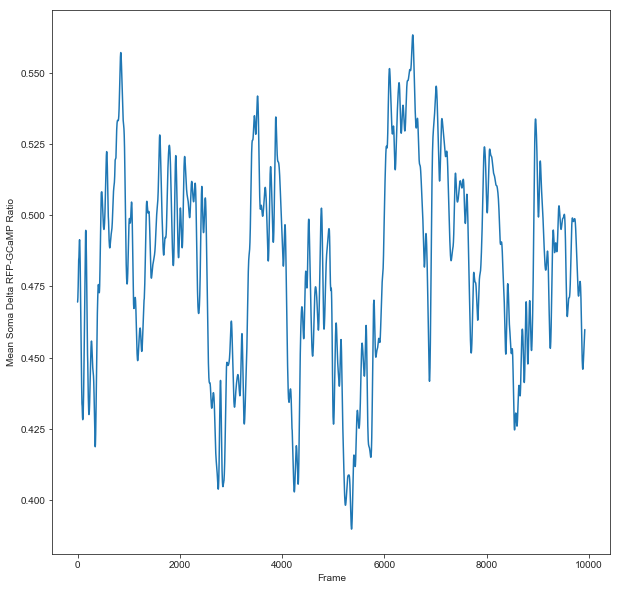

In [32]:
for frame in data.keys():
    temp_RFP = np.nanmean(list(data[frame][:,13].astype(float)))
    temp_GCaMP = np.nanmean(list(data[frame][:,16].astype(float)))
    Soma_RFP_mean.append(temp_RFP)
    Soma_GCaMP_mean.append(temp_GCaMP)
    SomaRatio.append(temp_GCaMP/temp_RFP)
    frame_list7.append(int(frame)+len(xVals_smoothed))
    
frame_list_sorted7, Soma_RFP_mean_sorted, Soma_GCaMP_mean_sorted, Soma_Ratio_sorted = (list(t) for t in zip(*sorted(zip(frame_list7,\
                                                            Soma_RFP_mean, Soma_GCaMP_mean, SomaRatio))))


#where_out = eng.isoutlier(matlab.single(Soma_Ratio_sorted), 'mean')
#Soma_Ratio_sorted_outlierTrim = np.where(where_out, np.nan, Soma_Ratio_sorted)[0].tolist()
Soma_Ratio_smoothed = gaussian_filter1d(Soma_Ratio_sorted, sigma=17)

plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(frame_list_sorted7,Soma_Ratio_smoothed)
plt.xlabel('Frame')
plt.ylabel('Mean Soma Delta RFP-GCaMP Ratio')
plt.show()

<Figure size 432x288 with 0 Axes>

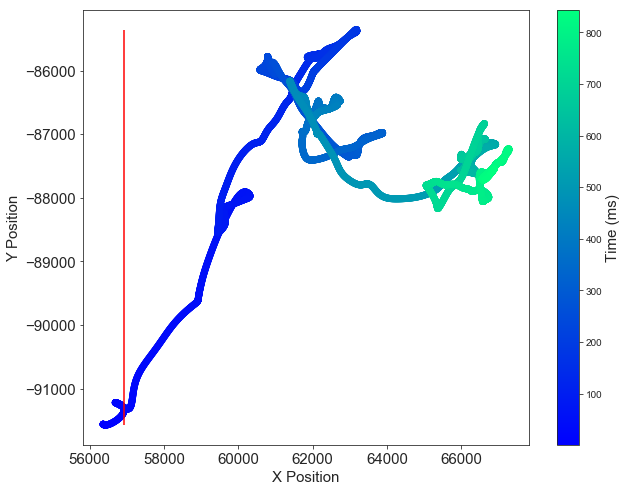

In [33]:
xVals_smoothed = gaussian_filter1d(xVal, sigma=30)
yVals_smoothed = gaussian_filter1d(yVal, sigma=30)

plt.clf()
plt.figure(figsize=(10,8))#,dpi=300)#plt.ylim(0,1)
plt.scatter(xVals_smoothed, yVals_smoothed, c=Time_sorted, cmap='winter')
plt.vlines(Theta_XPos[2000],ymin=min(yVals_smoothed),ymax=max(yVals_smoothed), color='r')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)
plt.xlabel('X Position', fontsize=15)
plt.ylabel('Y Position', fontsize=15)
cb = plt.colorbar()
cb.set_label('Time (ms)', fontsize=15)
plt.show()

<Figure size 432x288 with 0 Axes>

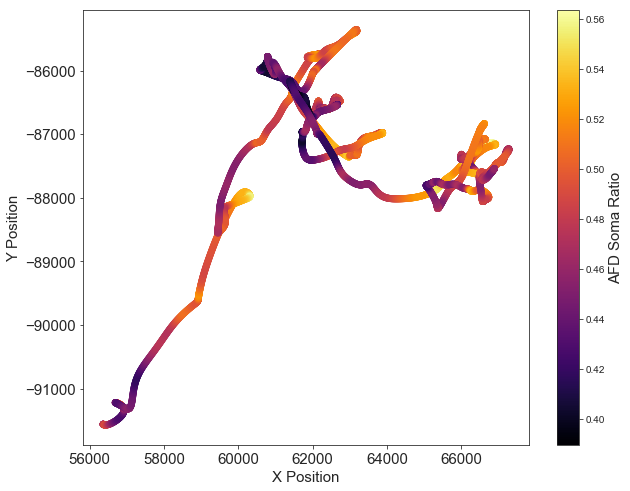

In [34]:
plt.clf()
plt.figure(figsize=(10,8))#,dpi=300)#plt.ylim(0,1)
plt.scatter(xVals_smoothed, yVals_smoothed, c=Soma_Ratio_smoothed, cmap='inferno', vmin=min(Soma_Ratio_smoothed), vmax=max(Soma_Ratio_smoothed))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)
plt.xlabel('X Position', fontsize=15)
plt.ylabel('Y Position', fontsize=15)
cb = plt.colorbar()
cb.set_label('AFD Soma Ratio', fontsize=15)
plt.show()

In [35]:
response_indeces_smooth = []
cooling_indeces_smooth = []
for i in range(1,len(theta_smooth)-1):
    if theta_smooth[i] <  smoothed_TxTip[i] and theta_smooth[i+1] <  (smoothed_TxTip[i+1]-0.0001) \
    and theta_smooth[i-1] >= smoothed_TxTip[i-1]:
        response_indeces_smooth.append(i)
    elif theta_smooth[i] >  smoothed_TxTip[i] and theta_smooth[i+1] > (smoothed_TxTip[i+1]+0.0001) \
    and theta_smooth[i-1] <= smoothed_TxTip[i-1]:
        cooling_indeces_smooth.append(i)

In [36]:
print(cooling_indeces_smooth)
print(response_indeces_smooth)

[]
[]


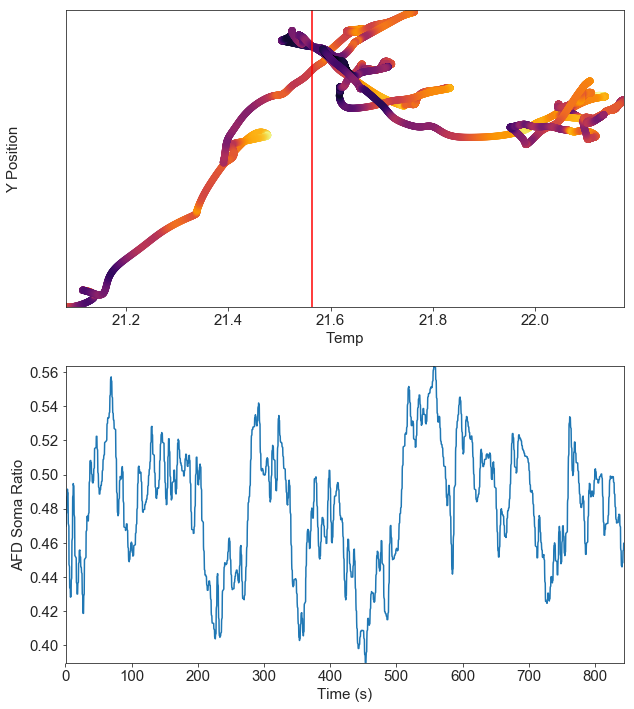

In [37]:
frame_num = len(Soma_Ratio_smoothed)-1

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(10,12))
ax1 = plt.subplot(2,1,1)
ax2 = plt.subplot(2,1,2)
#cb = plt.colorbar()
#cb.set_label('AFD Soma Ratio', fontsize=15)


# clear
ax1.clear()
ax2.clear()

# plotting line
ax1.scatter(smoothed_TxTip[:frame_num], yVals_smoothed[:frame_num], c=Soma_Ratio_smoothed[:frame_num], cmap='inferno', vmin=min(Soma_Ratio_smoothed), vmax=max(Soma_Ratio_smoothed))
ax1.vlines(theta_smooth[frame_num], ymin=min(yVals_smoothed), ymax=max(yVals_smoothed), colors='r')
ax1.tick_params(axis='y', colors='white')
ax1.tick_params(axis='x', labelsize=15)
ax1.set_xlim(xmin=min(smoothed_TxTip),xmax=max(smoothed_TxTip))
ax1.set_ylim(ymin=min(yVals_smoothed),ymax=max(yVals_smoothed))
ax1.set_ylabel('Y Position', fontsize=15)
ax1.set_xlabel('Temp', fontsize=15)

ax2.plot(Time_sorted[:frame_num], Soma_Ratio_smoothed[:frame_num])

for i in response_indeces_smooth:
    if frame_num > i:
        ax2.vlines(Time_sorted[i], ymin=min(Soma_Ratio_smoothed), ymax=max(Soma_Ratio_smoothed), colors='r')
for i in cooling_indeces_smooth:
    if frame_num > i:
        ax2.vlines(Time_sorted[i], ymin=min(Soma_Ratio_smoothed), ymax=max(Soma_Ratio_smoothed), colors='b')
    #response_indeces_smooth.pop(0)
ax2.tick_params(axis = 'both', labelsize=15)
ax2.set_xlim(xmin=min(Time_sorted),xmax=max(Time_sorted))
ax2.set_ylim(ymin=min(Soma_Ratio_smoothed),ymax=max(Soma_Ratio_smoothed))
ax2.set_ylabel('AFD Soma Ratio', fontsize=15)
ax2.set_xlabel('Time (s)', fontsize=15)

plt.show()

<Figure size 432x288 with 0 Axes>

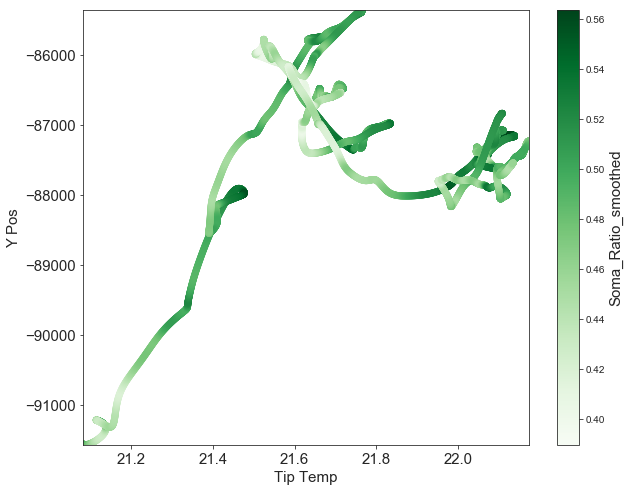

In [58]:
#test_frame = 4070
test_frame = 9900
plt.clf()
plt.figure(figsize=(10,8))#,dpi=300)#plt.ylim(0,1)
plt.scatter(smoothed_TxTip[:test_frame], yVals_smoothed[:test_frame], c=Soma_Ratio_smoothed[:test_frame], cmap='Greens', vmin=min(Soma_Ratio_smoothed), vmax=max(Soma_Ratio_smoothed))
for i in response_indeces_smooth:
    if test_frame > i:
        plt.axvline(smoothed_TxTip[i], c='r')
for i in cooling_indeces_smooth:
    if test_frame > i:
        plt.axvline(smoothed_TxTip[i], c='b')
plt.tick_params(axis = 'both', labelsize=15)
plt.xlim(xmin=min(smoothed_TxTip),xmax=max(smoothed_TxTip))
plt.ylim(ymin=min(yVals_smoothed),ymax=max(yVals_smoothed))
plt.ylabel('Y Pos', fontsize=15)
plt.xlabel('Tip Temp', fontsize=15)
plt.colorbar().set_label(label='Soma_Ratio_smoothed',size=15)
plt.show()

In [39]:
print(len(smoothed_TxTip))
print(len(yVals_smoothed))

9903
9903


In [40]:
def calc_Delta(Soma_Ratio_smoothed):
    Delta_Soma_Ratio_smoothed = []
    rat_min = min(Soma_Ratio_smoothed)
    for i in Soma_Ratio_smoothed:
        Delta_Soma_Ratio_smoothed.append((i-rat_min)/rat_min)
    
    return(Delta_Soma_Ratio_smoothed)

In [41]:
Delta_Soma_Ratio_smoothed = calc_Delta(Soma_Ratio_smoothed)
print(Delta_Soma_Ratio_smoothed)

[0.204936056922254, 0.2051280182912048, 0.20550869289455576, 0.20607837175547025, 0.2068340512501971, 0.20777273602979981, 0.20888905495895443, 0.21017707548056244, 0.2116312733113869, 0.21324319315877563, 0.21500470732842578, 0.2169055776264472, 0.21893438325969528, 0.221078941887303, 0.2233263973220317, 0.22566080610630543, 0.22806581843944915, 0.23052521624743125, 0.23301592546507757, 0.2355288436494764, 0.23803318374164484, 0.24051901769460224, 0.24295950417420234, 0.24533272738333398, 0.24761736375101745, 0.24979123763129496, 0.2518327752938393, 0.25372180327252064, 0.25543794454626195, 0.2569624800607067, 0.2582764371004556, 0.2593645147478997, 0.2602119604188482, 0.26080552524019945, 0.2611337781272308, 0.2611853846460255, 0.26095688773141446, 0.26044671345422243, 0.2596455732145371, 0.25855704504744664, 0.2571879965110879, 0.2555380205826652, 0.2536136129356233, 0.25142532429773695, 0.2489832479220556, 0.24629847383331735, 0.24338607877370058, 0.24026068269585293, 0.23693845001

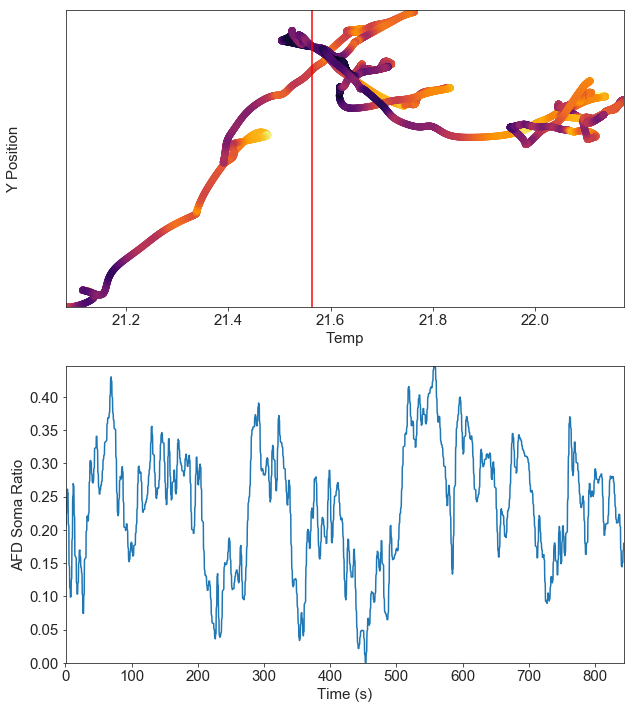

In [42]:
frame_num = len(Delta_Soma_Ratio_smoothed)-1

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(10,12))
ax1 = plt.subplot(2,1,1)
ax2 = plt.subplot(2,1,2)
#cb = plt.colorbar()
#cb.set_label('AFD Soma Ratio', fontsize=15)


# clear
ax1.clear()
ax2.clear()

# plotting line
ax1.scatter(smoothed_TxTip[:frame_num], yVals_smoothed[:frame_num], c=Delta_Soma_Ratio_smoothed[:frame_num], cmap='inferno', vmin=min(Delta_Soma_Ratio_smoothed), vmax=max(Delta_Soma_Ratio_smoothed))
ax1.vlines(theta_smooth[frame_num], ymin=min(yVals_smoothed), ymax=max(yVals_smoothed), colors='r')
ax1.tick_params(axis='y', colors='white')
ax1.tick_params(axis='x', labelsize=15)
ax1.set_xlim(xmin=min(smoothed_TxTip),xmax=max(smoothed_TxTip))
ax1.set_ylim(ymin=min(yVals_smoothed),ymax=max(yVals_smoothed))
ax1.set_ylabel('Y Position', fontsize=15)
ax1.set_xlabel('Temp', fontsize=15)

ax2.plot(Time_sorted[:frame_num], Delta_Soma_Ratio_smoothed[:frame_num])

for i in response_indeces_smooth:
    if frame_num > i:
        ax2.vlines(Time_sorted[i], ymin=min(Delta_Soma_Ratio_smoothed), ymax=max(Delta_Soma_Ratio_smoothed), colors='r')
for i in cooling_indeces_smooth:
    if frame_num > i:
        ax2.vlines(Time_sorted[i], ymin=min(Delta_Soma_Ratio_smoothed), ymax=max(Delta_Soma_Ratio_smoothed), colors='b')
    #response_indeces_smooth.pop(0)
ax2.tick_params(axis = 'both', labelsize=15)
ax2.set_xlim(xmin=min(Time_sorted),xmax=max(Time_sorted))
ax2.set_ylim(ymin=min(Delta_Soma_Ratio_smoothed),ymax=max(Delta_Soma_Ratio_smoothed))
ax2.set_ylabel('AFD Soma Ratio', fontsize=15)
ax2.set_xlabel('Time (s)', fontsize=15)

plt.show()

In [43]:
def plot_real_model_data(Delta_Soma_Ratio_smoothed, C, title):
    fig = plt.subplots(nrows = 1, ncols = 1, figsize=(10,8))

    plt.plot(Time_sorted[:frame_num], Delta_Soma_Ratio_smoothed[:frame_num], 'r', lw=5)
    plt.plot(Time_sorted[:frame_num], C[:frame_num], 'b', lw=5)
    
    plt.xlim(xmin=min(Time_sorted),xmax=max(Time_sorted))
    plt.ylim(ymin=0,ymax=0.7)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.tick_params(axis='both', which='minor', labelsize=15)
    plt.xlabel('Time (s)', fontsize=15)
    plt.ylabel('AFD Soma Delta R/R', fontsize=15)
    plt.title(title, fontsize=20)
    plt.savefig(title+'.png')
    plt.show()
    plt.close()

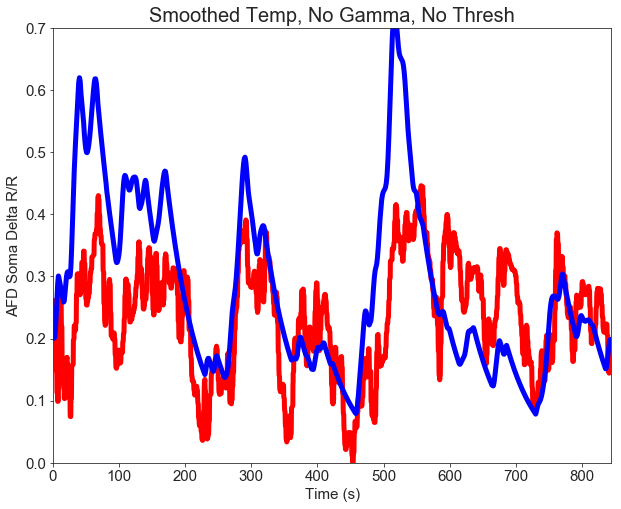

In [44]:
## Without Thresh Without Gamma ##

above_threshold = [0]
check = 0
for i in range(1,len(theta_smooth)-1):
    if theta_smooth[i] <  smoothed_TxTip[i] and theta_smooth[i+1] <  (smoothed_TxTip[i+1]-0.0001) \
    and theta_smooth[i-1] >= smoothed_TxTip[i-1] and check == 0:
        above_threshold.append(1)
        check = 1
    elif theta_smooth[i] <  smoothed_TxTip[i] and check == 1:
        above_threshold.append(1)
    elif theta_smooth[i] > smoothed_TxTip[i] and check == 1:
        above_threshold.append(0)
        check = 0
    elif theta_smooth[i] > smoothed_TxTip[i] and check == 0:
        above_threshold.append(0)
    else:
        #print(theta_smooth[i], smoothed_TxTip[i], check, i, 'Missed')
        above_threshold.append(0)
above_threshold.append(1)

temp_deriv = np.append([0], np.diff(smoothed_TxTip))
temp_deriv2 = []
for i in range(len(temp_deriv)):
    if temp_deriv[i] < 0.0001:
        temp_deriv2.append(0)
    else:
        temp_deriv2.append(temp_deriv[i])

I = temp_deriv2

tau = 10
dif_T = 0.1
alpha = 0.2
beta = 0.4
c=400

C = np.array(Delta_Soma_Ratio_smoothed)
#print C[0]
for i in range(1,len(Delta_Soma_Ratio_smoothed)):
    if I[i]>0:
        C[i] = C[i-1] + ((-beta*C[i-1] + c*I[i])/tau)*diffT[i]
    else:
        C[i] = C[i-1] + ((-alpha*C[i-1])/tau)*diffT[i]
        
plot_real_model_data(Delta_Soma_Ratio_smoothed, C, 'Smoothed Temp, No Gamma, No Thresh')

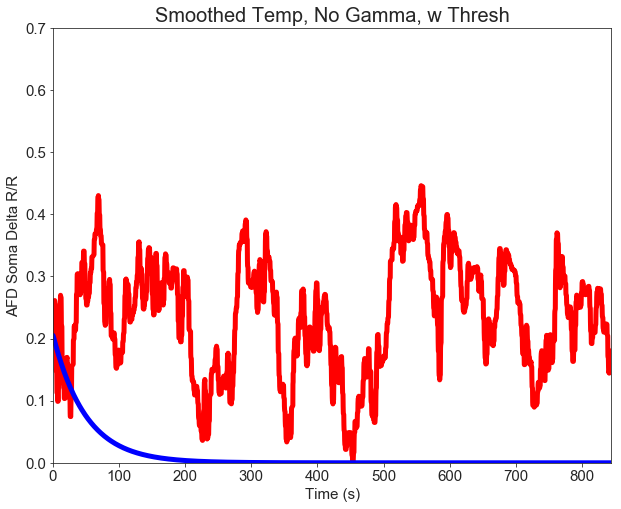

In [45]:
## Without Gamma ##

above_threshold = [0]
check = 0
for i in range(1,len(theta_smooth)-1):
    if theta_smooth[i] <  smoothed_TxTip[i] and theta_smooth[i+1] <  (smoothed_TxTip[i+1]-0.0001) \
    and theta_smooth[i-1] >= smoothed_TxTip[i-1] and check == 0:
        above_threshold.append(1)
        check = 1
    elif theta_smooth[i] <  smoothed_TxTip[i] and check == 1:
        above_threshold.append(1)
    elif theta_smooth[i] > smoothed_TxTip[i] and check == 1:
        above_threshold.append(0)
        check = 0
    elif theta_smooth[i] > smoothed_TxTip[i] and check == 0:
        above_threshold.append(0)
    else:
        #print(theta_smooth[i], smoothed_TxTip[i], check, i, 'Missed')
        above_threshold.append(0)
above_threshold.append(1)

temp_deriv = np.append([0], np.diff(smoothed_TxTip))
temp_deriv2 = []
for i in range(len(temp_deriv)):
    if temp_deriv[i] < 0.0001 or above_threshold[i] == 0:
        temp_deriv2.append(0)
    else:
        temp_deriv2.append(temp_deriv[i])

I = temp_deriv2

tau = 10
dif_T = 0.1
alpha = 0.2
beta = 0.4
c=400

C = np.array(Delta_Soma_Ratio_smoothed)
#print C[0]
for i in range(1,len(Delta_Soma_Ratio_smoothed)):
    if I[i]>0:
        C[i] = C[i-1] + ((-beta*C[i-1] + c*I[i])/tau)*diffT[i]
    else:
        C[i] = C[i-1] + ((-alpha*C[i-1])/tau)*diffT[i]
        
plot_real_model_data(Delta_Soma_Ratio_smoothed, C, 'Smoothed Temp, No Gamma, w Thresh')

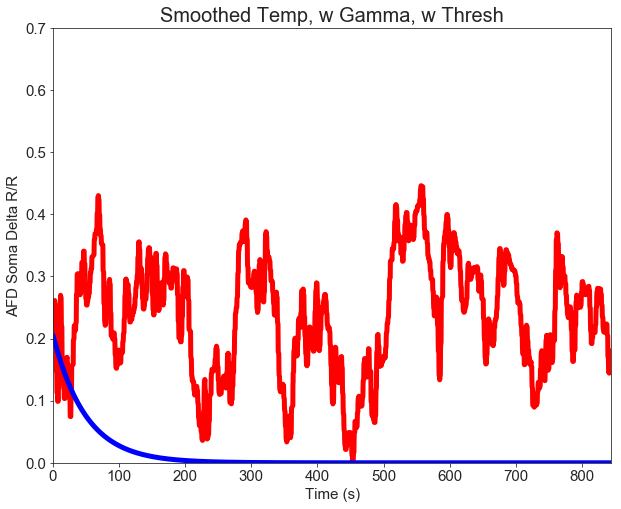

In [46]:
## with both ##

above_threshold = [0]
check = 0
for i in range(1,len(theta_smooth)-1):
    if theta_smooth[i] <  smoothed_TxTip[i] and theta_smooth[i+1] <  (smoothed_TxTip[i+1]-0.0001) \
    and theta_smooth[i-1] >= smoothed_TxTip[i-1] and check == 0:
        above_threshold.append(1)
        check = 1
    elif theta_smooth[i] <  smoothed_TxTip[i] and check == 1:
        above_threshold.append(1)
    elif theta_smooth[i] > smoothed_TxTip[i] and check == 1:
        above_threshold.append(0)
        check = 0
    elif theta_smooth[i] > smoothed_TxTip[i] and check == 0:
        above_threshold.append(0)
    else:
        #print(theta_smooth[i], smoothed_TxTip[i], check, i, 'Missed')
        above_threshold.append(0)
above_threshold.append(1)

from scipy.stats import gamma
percept_range_bottom = 19.8
gamma_param = 3.5

temp_deriv = np.append([0], np.diff(smoothed_TxTip))
temp_deriv2 = []
for i in range(len(temp_deriv)):
    if temp_deriv[i] < 0.0001 or above_threshold[i] == 0:
        temp_deriv2.append(0)
    elif smoothed_TxTip[i] < percept_range_bottom:
        temp_deriv2.append(0)
    else:
        scaling_factor = gamma.pdf(smoothed_TxTip[i]-percept_range_bottom,gamma_param)
        temp_deriv2.append(scaling_factor*temp_deriv[i])

I = temp_deriv2

tau = 10
dif_T = 0.1
alpha = 0.2
beta = 0.4
c=2000

C = np.array(Delta_Soma_Ratio_smoothed)
#print C[0]
for i in range(1,len(Delta_Soma_Ratio_smoothed)):
    if I[i]>0:
        C[i] = C[i-1] + ((-beta*C[i-1] + c*I[i])/tau)*diffT[i]
    else:
        C[i] = C[i-1] + ((-alpha*C[i-1])/tau)*diffT[i]
        
plot_real_model_data(Delta_Soma_Ratio_smoothed, C, 'Smoothed Temp, w Gamma, w Thresh')

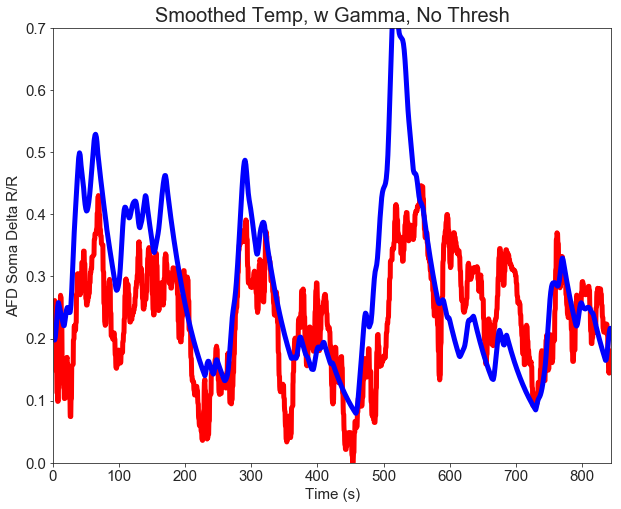

In [47]:
## with gamma no thresh ##

above_threshold = [0]
check = 0
for i in range(1,len(theta_smooth)-1):
    if theta_smooth[i] <  smoothed_TxTip[i] and theta_smooth[i+1] <  (smoothed_TxTip[i+1]-0.0001) \
    and theta_smooth[i-1] >= smoothed_TxTip[i-1] and check == 0:
        above_threshold.append(1)
        check = 1
    elif theta_smooth[i] <  smoothed_TxTip[i] and check == 1:
        above_threshold.append(1)
    elif theta_smooth[i] > smoothed_TxTip[i] and check == 1:
        above_threshold.append(0)
        check = 0
    elif theta_smooth[i] > smoothed_TxTip[i] and check == 0:
        above_threshold.append(0)
    else:
        #print(theta_smooth[i], smoothed_TxTip[i], check, i, 'Missed')
        above_threshold.append(0)
above_threshold.append(1)

from scipy.stats import gamma
percept_range_bottom = 19.8
gamma_param = 3.5

temp_deriv = np.append([0], np.diff(smoothed_TxTip))
temp_deriv2 = []
for i in range(len(temp_deriv)):
    if temp_deriv[i] < 0.0001:
        temp_deriv2.append(0)
    elif smoothed_TxTip[i] < percept_range_bottom:
        temp_deriv2.append(0)
    else:
        scaling_factor = gamma.pdf(smoothed_TxTip[i]-percept_range_bottom,gamma_param)
        temp_deriv2.append(scaling_factor*temp_deriv[i])

I = temp_deriv2

tau = 10
dif_T = 0.1
alpha = 0.2
beta = 0.4
c=1800

C = np.array(Delta_Soma_Ratio_smoothed)
#print C[0]
for i in range(1,len(Delta_Soma_Ratio_smoothed)):
    if I[i]>0:
        C[i] = C[i-1] + ((-beta*C[i-1] + c*I[i])/tau)*diffT[i]
    else:
        C[i] = C[i-1] + ((-alpha*C[i-1])/tau)*diffT[i]
        
plot_real_model_data(Delta_Soma_Ratio_smoothed, C, 'Smoothed Temp, w Gamma, No Thresh')

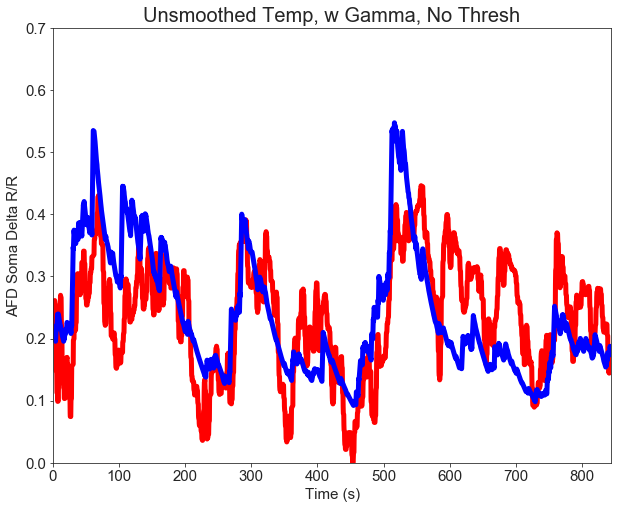

In [48]:
## with gamma no thresh, trying with unsmoothed temp ##

above_threshold = [0]
check = 0
for i in range(1,len(theta_smooth)-1):
    if theta_smooth[i] <  TxTip[i] and theta_smooth[i+1] <  (TxTip[i+1]-0.0001) \
    and theta_smooth[i-1] >= TxTip[i-1] and check == 0:
        above_threshold.append(1)
        check = 1
    elif theta_smooth[i] <  TxTip[i] and check == 1:
        above_threshold.append(1)
    elif theta_smooth[i] > TxTip[i] and check == 1:
        above_threshold.append(0)
        check = 0
    elif theta_smooth[i] > TxTip[i] and check == 0:
        above_threshold.append(0)
    else:
        #print(theta_smooth[i], TxTip[i], check, i, 'Missed')
        above_threshold.append(0)
above_threshold.append(1)

from scipy.stats import gamma
percept_range_bottom = 20
gamma_param = 3.5

temp_deriv = np.append([0], np.diff(TxTip))
temp_deriv2 = []
for i in range(len(temp_deriv)):
    if temp_deriv[i] < 0.0001:
        temp_deriv2.append(0)
    elif TxTip[i] < percept_range_bottom:
        temp_deriv2.append(0)
    else:
        scaling_factor = gamma.pdf(TxTip[i]-percept_range_bottom,gamma_param)
        temp_deriv2.append(scaling_factor*temp_deriv[i])

I = temp_deriv2

tau = 10
dif_T = 0.1
alpha = 0.2
beta = 0.4
c=140

C = np.array(Delta_Soma_Ratio_smoothed)
#print C[0]
for i in range(1,len(Delta_Soma_Ratio_smoothed)):
    if I[i]>0:
        C[i] = C[i-1] + ((-beta*C[i-1] + c*I[i])/tau)*diffT[i]
    else:
        C[i] = C[i-1] + ((-alpha*C[i-1])/tau)*diffT[i]
        
plot_real_model_data(Delta_Soma_Ratio_smoothed, C, 'Unsmoothed Temp, w Gamma, No Thresh')

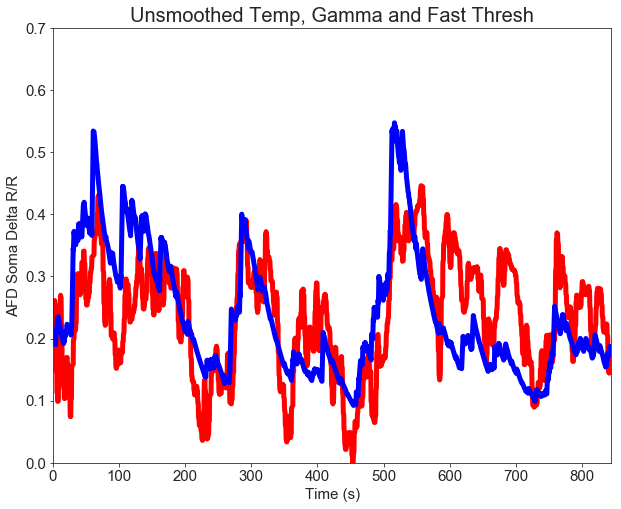

In [49]:
## with gamma and thresh, trying with unsmoothed temp ##

above_threshold = [0]
check = 0
for i in range(1,len(theta_smooth)-1):
    if theta_smooth[i] <  TxTip[i] and theta_smooth[i+1] <  (TxTip[i+1]-0.0001) \
    and theta_smooth[i-1] >= TxTip[i-1] and check == 0:
        above_threshold.append(1)
        check = 1
    elif theta_smooth[i] <  TxTip[i] and check == 1:
        above_threshold.append(1)
    elif theta_smooth[i] > TxTip[i] and check == 1:
        above_threshold.append(0)
        check = 0
    elif theta_smooth[i] > TxTip[i] and check == 0:
        above_threshold.append(0)
    else:
        #print(theta_smooth[i], TxTip[i], check, i, 'Missed')
        above_threshold.append(0)
above_threshold.append(1)

from scipy.stats import gamma
percept_range_bottom = 20
gamma_param = 3.5

temp_deriv = np.append([0], np.diff(TxTip))
temp_deriv2 = []
for i in range(len(temp_deriv)):
    if temp_deriv[i] < 0.0001 or above_threshold[i] == 0:
        temp_deriv2.append(0)
    elif TxTip[i] < percept_range_bottom:
        temp_deriv2.append(0)
    else:
        scaling_factor = gamma.pdf(TxTip[i]-percept_range_bottom,gamma_param)
        temp_deriv2.append(scaling_factor*temp_deriv[i])

I = temp_deriv2

tau = 10
dif_T = 0.1
alpha = 0.2
beta = 0.4
c=140

C = np.array(Delta_Soma_Ratio_smoothed)
#print C[0]
for i in range(1,len(Delta_Soma_Ratio_smoothed)):
    if I[i]>0:
        C[i] = C[i-1] + ((-beta*C[i-1] + c*I[i])/tau)*diffT[i]
    else:
        C[i] = C[i-1] + ((-alpha*C[i-1])/tau)*diffT[i]
        
plot_real_model_data(Delta_Soma_Ratio_smoothed, C, 'Unsmoothed Temp, Gamma and Fast Thresh')

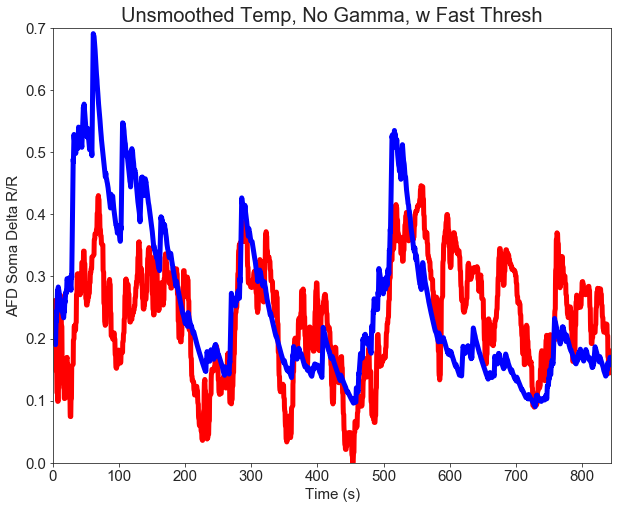

In [50]:
above_threshold = [0]
check = 0
for i in range(1,len(theta_smooth)-1):
    if theta_smooth[i] <  TxTip[i] and theta_smooth[i+1] <  (TxTip[i+1]-0.0001) \
    and theta_smooth[i-1] >= TxTip[i-1] and check == 0:
        above_threshold.append(1)
        check = 1
    elif theta_smooth[i] <  TxTip[i] and check == 1:
        above_threshold.append(1)
    elif theta_smooth[i] > TxTip[i] and check == 1:
        above_threshold.append(0)
        check = 0
    elif theta_smooth[i] > TxTip[i] and check == 0:
        above_threshold.append(0)
    else:
        #print(theta_smooth[i], TxTip[i], check, i, 'Missed')
        above_threshold.append(0)
above_threshold.append(1)

temp_deriv = np.append([0], np.diff(TxTip))
temp_deriv2 = []
for i in range(len(temp_deriv)):
    if temp_deriv[i] < 0.0001 or above_threshold[i] == 0:
        temp_deriv2.append(0)
    else:
        temp_deriv2.append(temp_deriv[i])

I = temp_deriv2

tau = 10
dif_T = 0.1
alpha = 0.2
beta = 0.4
c=30

C = np.array(Delta_Soma_Ratio_smoothed)
#print C[0]
for i in range(1,len(Delta_Soma_Ratio_smoothed)):
    if I[i]>0:
        C[i] = C[i-1] + ((-beta*C[i-1] + c*I[i])/tau)*diffT[i]
    else:
        C[i] = C[i-1] + ((-alpha*C[i-1])/tau)*diffT[i]
        
plot_real_model_data(Delta_Soma_Ratio_smoothed, C, 'Unsmoothed Temp, No Gamma, w Fast Thresh')

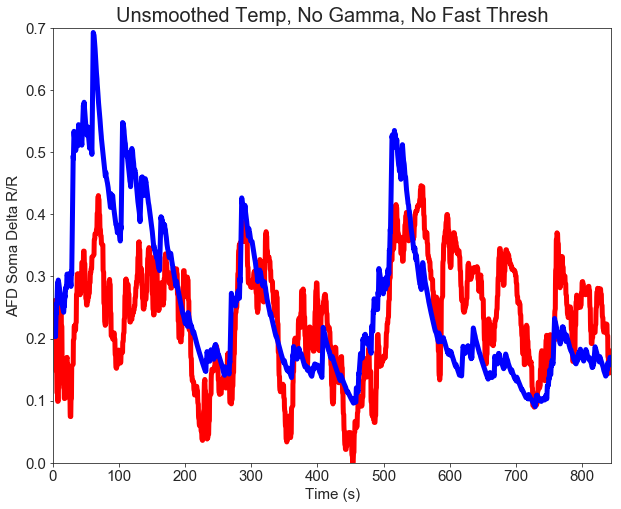

In [51]:
above_threshold = [0]
check = 0
for i in range(1,len(theta_smooth)-1):
    if theta_smooth[i] <  TxTip[i] and theta_smooth[i+1] <  (TxTip[i+1]-0.0001) \
    and theta_smooth[i-1] >= TxTip[i-1] and check == 0:
        above_threshold.append(1)
        check = 1
    elif theta_smooth[i] <  TxTip[i] and check == 1:
        above_threshold.append(1)
    elif theta_smooth[i] > TxTip[i] and check == 1:
        above_threshold.append(0)
        check = 0
    elif theta_smooth[i] > TxTip[i] and check == 0:
        above_threshold.append(0)
    else:
        #print(theta_smooth[i], TxTip[i], check, i, 'Missed')
        above_threshold.append(0)
above_threshold.append(1)

temp_deriv = np.append([0], np.diff(TxTip))
temp_deriv2 = []
for i in range(len(temp_deriv)):
    if temp_deriv[i] < 0.0001:
        temp_deriv2.append(0)
    else:
        temp_deriv2.append(temp_deriv[i])

I = temp_deriv2

tau = 10
dif_T = 0.1
alpha = 0.2
beta = 0.4
c=30

C = np.array(Delta_Soma_Ratio_smoothed)
#print C[0]
for i in range(1,len(Delta_Soma_Ratio_smoothed)):
    if I[i]>0:
        C[i] = C[i-1] + ((-beta*C[i-1] + c*I[i])/tau)*diffT[i]
    else:
        C[i] = C[i-1] + ((-alpha*C[i-1])/tau)*diffT[i]
        
plot_real_model_data(Delta_Soma_Ratio_smoothed, C, 'Unsmoothed Temp, No Gamma, No Fast Thresh')

In [52]:
print('test')

test
